In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Read dataset
df = pd.read_csv("Dataset_Day11.csv")

# Columns having missing values
cols = ['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction']

# Replace 0 with NaN
for col in cols:
    df[col] = df[col].replace(0,np.nan)

# Fill missing values using median
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# Remove outliers using IQR method
for col in cols:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Lower and upper limits
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    # Find outlier rows
    OutlierRows = df[(df[col] < lower) | (df[col] > upper)]

    # Remove outliers
    df = df.drop(OutlierRows.index)

# Display final shape
print(df.shape)
print(df.head())

(719, 7)
   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6    148.0           72.0  33.6                     0.627   50   
1            1     85.0           66.0  26.6                     0.351   31   
2            8    183.0           64.0  23.3                     0.672   32   
3            1     89.0           66.0  28.1                     0.167   21   
5            5    116.0           74.0  25.6                     0.201   30   

   Outcome  
0        1  
1        0  
2        1  
3        0  
5        0  


In [3]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Separate input and output
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=99
)

# Create Bagging model
bag = BaggingClassifier()

# Train model
bag.fit(X_train, y_train)

# Predict test data
y_pred = bag.predict(X_test)

# Print performance metrics
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Accuracy = 0.7430555555555556
Precision = 0.6285714285714286
Recall = 0.4782608695652174
F1 Score = 0.5432098765432098


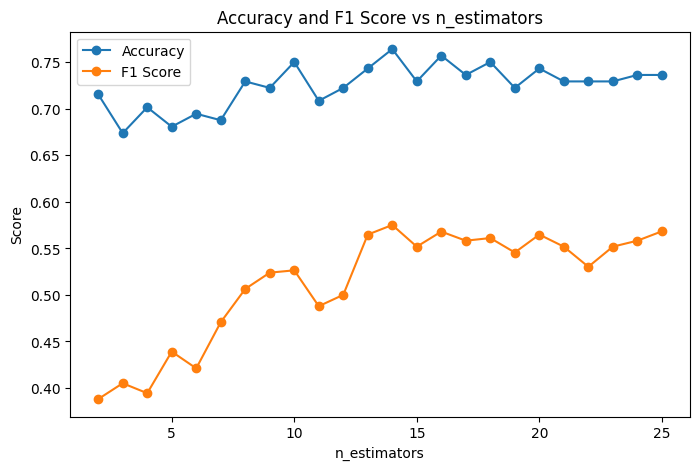

In [4]:
# Lists to store scores
accuracy_list = []
f1_list = []

# Different values of n_estimators
n_range = range(2,26)

for n in n_range:

    # Create model
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        random_state=99
    )

    # Train model
    bag.fit(X_train, y_train)

    # Predict
    y_pred = bag.predict(X_test)

    # Store scores
    accuracy_list.append(accuracy_score(y_test,y_pred))
    f1_list.append(f1_score(y_test,y_pred))

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(n_range, accuracy_list, marker='o', label='Accuracy')

plt.plot(n_range, f1_list, marker='o', label='F1 Score')

plt.xlabel("n_estimators")
plt.ylabel("Score")

plt.title("Accuracy and F1 Score vs n_estimators")

plt.legend()

plt.show()

In [5]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(random_state=99)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Print performance metrics
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Accuracy = 0.7361111111111112
Precision = 0.6052631578947368
Recall = 0.5
F1 Score = 0.5476190476190477


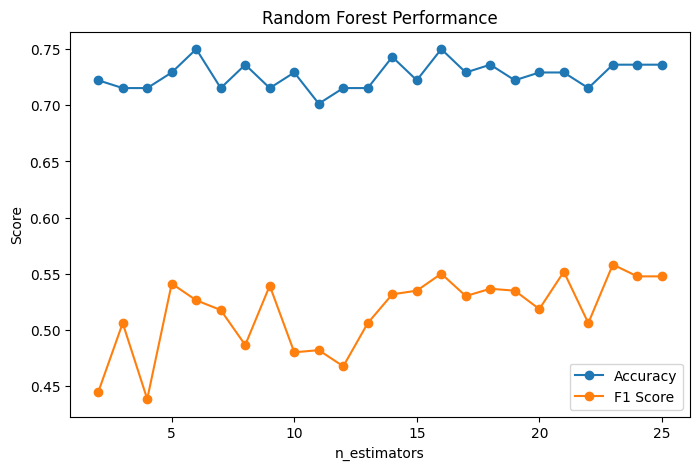

In [6]:
accuracy_list = []
f1_list = []

n_range = range(2,26)

for n in n_range:

    # Create model
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=99
    )

    # Train model
    rf.fit(X_train, y_train)

    # Predict
    y_pred = rf.predict(X_test)

    # Store scores
    accuracy_list.append(accuracy_score(y_test,y_pred))
    f1_list.append(f1_score(y_test,y_pred))

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(n_range, accuracy_list, marker='o', label='Accuracy')

plt.plot(n_range, f1_list, marker='o', label='F1 Score')

plt.xlabel("n_estimators")
plt.ylabel("Score")

plt.title("Random Forest Performance")

plt.legend()

plt.show()

In [7]:
# Import AdaBoost
from sklearn.ensemble import AdaBoostClassifier

# Create model
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=99
)

# Train model
ada.fit(X_train, y_train)

# Predict
y_pred = ada.predict(X_test)

# Print performance metrics
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Accuracy = 0.6319444444444444
Precision = 0.425531914893617
Recall = 0.43478260869565216
F1 Score = 0.43010752688172044


In [ ]:
#After comparing the performance of Bagging, Random Forest, and AdaBoost models, 
# it was observed that Random Forest achieved the highest F1 Score and 
# gave the best overall performance. Therefore, Random Forest is the most suitable model 
# for predicting diabetes in this dataset.